# Autoencoder pour la détection d'anomalies

Construire un Autoencoder avec Keras/PyTorch. Entraîner sur le trafic normal. Détecter les anomalies via l'erreur de reconstruction. Tester différentes architectures (nb couches, taille latente). Livrable : notebook autoencoder.ipynb.

## Définition

Un Autoencoder est un réseau de neurones qui apprend à compresser les données puis à les reconstruire. Il est composé de deux parties :

- **Encodeur** : compresse les données d'entrée vers un espace de dimension réduite appelé espace latent. L'espace latent de taille n signifie qu'on résume toute une connexion réseau en seulement n nombres. Plus ce nombre est petit, plus la compression est agressive ainsi le modèle est forcé de ne garder que l'essentiel du trafic normal.
- **Décodeur** : reconstruit les données originales à partir de cet espace latent

Pour la détection d'anomalies on entraîne le modèle uniquement sur du trafic normal ainsi il apprend à bien compresser et décompresser le trafic normal. Ensuite face à une attaque, il ne sait pas la reconstruire car il n'en a jamais vu donc l'erreur de reconstruction sera élevée puis on fixe un seuil et si l'erreur dépasse ce seuil, c'est une anomalie.

Les 3 architectures qu'on teste correspondent à des profondeurs différentes : légère, moyenne et profonde, pour voir laquelle reconstruit le mieux le trafic normal tout en se trompant sur les attaques.

## Importation des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version : {tf.__version__}")

2026-04-28 10:47:53.185789: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version : 2.16.2


In [2]:
chemin_CICIDS = '../Data/cicids_clean.csv'
chemin_UNSW   = '../Data/unsw_clean.csv'
chemin_LOGS   = '../Data/logs_clean.csv'

df_cicids = pd.read_csv(chemin_CICIDS, low_memory=False)
df_unsw = pd.read_csv(chemin_UNSW,low_memory=False)
df_logs = pd.read_csv(chemin_LOGS,low_memory=False)


## Fonction utilitaire : construction de l'autoencoder

On définit une fonction qui construit un autoencoder avec des paramètres variables pour tester différentes architectures.

On crée d'abord une première fonction build_autoencoder qui construit l'architecture du réseau de neurones. Elle prend en paramètres la dimension d'entrée (nombre de features), la taille de l'espace latent et la liste des couches cachées. Elle construit d'abord l'encodeur en empilant des couches qui réduisent progressivement la dimension, puis la couche latente qui est le point le plus compressé, puis le décodeur qui fait l'inverse en remontant vers la dimension originale. relu est la fonction d'activation qui introduit de la non-linéarité car sans elle le réseau ne pourrait apprendre que des relations linéaires simples. À la fin elle compile le modèle avec adam comme optimiseur et mse comme fonction de perte, c'est ce que le modèle va chercher à minimiser pendant l'entraînement.

On crée une seconde fonction detecter_anomalies qui utilise le modèle entraîné pour détecter les anomalies. Elle reconstruit le modèle  et essaie de reproduire les données qu'on lui donne. Par exemple on lui donne une connexion avec 79 features, il la compresse en 16 nombres puis la reconstruit en 79 features.
Ensuite elle calcul l'erreur car on compare feature par feature ce qu'on lui a donné et ce qu'il a reconstruit. Si on lui donne [1.2, 0.5, 3.1, ...] et qu'il reconstruit [1.1, 0.6, 3.0, ...] l'erreur est faible donc c'est du trafic normal qu'il connaît bien. Si il reconstruit [1.2, 5.8, 0.1, ...] l'erreur est élevée et c'est une attaque qu'il n'a jamais vue. Puis finalement on compare l'erreur au seuil qu'on a fixé. Si erreur > seuil alors c'est une anomalie (1), sinon le trafic est normal (0). Le seuil est calculé à partir des erreurs sur les données d'entraînement normales par une formule qui est : moyenne + 2 × écart-type et donc tout ce qui dépasse cette valeur est considéré comme anormal.

In [3]:
def build_autoencoder(input_dim, latent_dim, hidden_layers):
    inputs = keras.Input(shape=(input_dim,))  # couche d'entrée
    x = inputs

    # encodeur qui permet de réduire progressivement la dimension
    for units in hidden_layers:
        x = layers.Dense(units, activation='relu')(x)

    # espace latent donc représentation la plus compressée
    x = layers.Dense(latent_dim, activation='relu')(x)

    # décodeur qui permet de reconstruire progressivement la dimension originale 
    for units in reversed(hidden_layers):
        x = layers.Dense(units, activation='relu')(x)

    outputs = layers.Dense(input_dim, activation='linear')(x)  # couche de sortie qui est de la même dimension que l'entrée

    model = keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')  # on minimise l'erreur de reconstruction
    return model


def detecter_anomalies(model, X, seuil):
    reconstructions = model.predict(X, verbose=0)  # le modèle reconstruit les données
    erreurs = np.mean((X - reconstructions) ** 2, axis=1)  # erreur 
    return (erreurs > seuil).astype(int), erreurs  # seuil


## Dataset CIC-IDS-2017

### 1.1 Préparation des données

Contrairement aux notebooks précédents ici l'autoencoder s'entraîne uniquement sur le trafic normal donc on sépare donc les données en train (normaux uniquement) et test (normaux + attaques).

In [5]:
# features numériques et label
X = df_cicids.drop(columns=['Label']).select_dtypes(include=[np.number])
y_cicids = (df_cicids['Label'] != 'BENIGN').astype(int)  # 0 pour normal et 1 pour attaque
X = X.fillna(0).replace([np.inf, -np.inf], 0)  # nettoyage
X_scaled = StandardScaler().fit_transform(X)  # normalisation

# séparation normaux et attaques 
X_normal  = X_scaled[y_cicids == 0]
X_attaque = X_scaled[y_cicids == 1]

#X_train : 80% des connexions normales et utilisées pour entraîner l'autoencoder , X_test_normal : 20% des connexions normales donc mises de côté pour le test
X_train, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=42) #random_state=42 garantit que la division est toujours la même à chaque exécution 

# jeu de test final composé de normaux + attaques mélangés
n = len(X_test_normal)
idx = np.random.choice(len(X_attaque), size=min(n, len(X_attaque)), replace=False)
X_test = np.vstack([X_test_normal, X_attaque[idx]])  # on empile les deux
y_test = np.array([0] * n + [1] * len(idx))          # labels correspondants

print(f"Train (normaux) : {X_train.shape}")
print(f"Test (normaux et attaques): {X_test.shape} et {y_test.mean():.2%} d'attaques")

Train (normaux) : (76052, 79)
Test (normaux et attaques): (38028, 79) et 50.00% d'attaques


### 1.2 Test de différentes architectures

On teste 3 architectures avec des profondeurs et tailles latentes différentes pour identifier la meilleure configuration.

In [6]:
input_dim = X_train.shape[1]  # nombre de features en entrée

# 3 architectures à comparer : légère, moyenne, profonde
architectures = [
    {'nom': 'Légère  (1 couche, latent=8)',   'hidden': [32],           'latent': 8},
    {'nom': 'Moyenne (2 couches, latent=16)',  'hidden': [64, 32],       'latent': 16},
    {'nom': 'Profonde (3 couches, latent=32)', 'hidden': [128, 64, 32],  'latent': 32},
]

resultats_cicids = []  # stocke les résultats de chaque architecture

for arch in architectures:
    print(f"\nArchitecture : {arch['nom']}")

    # construction et entraînement 
    model = build_autoencoder(input_dim, arch['latent'], arch['hidden'])
    history = model.fit(
        X_train, X_train,       # le modèle apprend à reconstruire ses propres entrées
        epochs=30,              # le modèle va parcourir toutes les données d'entraînement 30 fois
        batch_size=256,         # au lieu de traiter tous les points d'un coup, le modèle les traite par lots de 256
        validation_split=0.1,  # 10% des données d'entraînement sont mises de côté pour surveiller que le modèle apprend vraiment et ne mémorise pas
    )

    # seuil 
    erreurs_train = np.mean((X_train - model.predict(X_train, verbose=0)) ** 2, axis=1)
    seuil = erreurs_train.mean() + 2 * erreurs_train.std()

    # détection sur le jeu de test (normaux + attaques)
    pred, erreurs_test = detecter_anomalies(model, X_test, seuil)
    auc = roc_auc_score(y_test, erreurs_test)

    print(classification_report(y_test, pred, target_names=['Normal', 'Attaque']))
    print(f"AUC-ROC : {auc:.3f} et seuil : {seuil:.4f}")

    resultats_cicids.append({
        'Architecture': arch['nom'],
        'history'     : history,       # courbes d'apprentissage
        'erreurs'     : erreurs_test,  # erreurs de reconstruction sur le test
        'pred'        : pred,          # prédictions 0/1
        'seuil'       : seuil,
        'auc'         : auc
    })


Architecture : Légère  (1 couche, latent=8)
              precision    recall  f1-score   support

      Normal       0.56      0.99      0.71     19014
     Attaque       0.96      0.20      0.34     19014

    accuracy                           0.60     38028
   macro avg       0.76      0.60      0.52     38028
weighted avg       0.76      0.60      0.52     38028

AUC-ROC : 0.956 et seuil : 0.7221

Architecture : Moyenne (2 couches, latent=16)
              precision    recall  f1-score   support

      Normal       0.56      1.00      0.72     19014
     Attaque       0.99      0.23      0.37     19014

    accuracy                           0.61     38028
   macro avg       0.77      0.61      0.54     38028
weighted avg       0.77      0.61      0.54     38028

AUC-ROC : 0.983 et seuil : 0.5903

Architecture : Profonde (3 couches, latent=32)
              precision    recall  f1-score   support

      Normal       0.51      1.00      0.68     19014
     Attaque       0.98      

On remarque le contraste entre l'AUC-ROC et le f1-score. Les trois architectures obtiennent des AUC excellentes (0.956, 0.983, 0.988) aisni le modèle sépare très bien les classes en termes de scores. Mais le f1-score sur les attaques reste faible (0.34, 0.37, 0.08) le modèle classe presque tout comme normal.
Sur le recall des attaques la légère détecte 20% des attaques, la moyenne 23% et la profonde seulement 4%. Plus l'architecture est profonde, plus le seuil monte et moins elle détecte d'attaques. La profonde avec latent=32 est trop grande car elle mémorise trop bien les données normales et les attaques, ce qui réduit l'erreur de reconstruction sur tout.
La meilleure architecture est la moyenne avec un bon compromis AUC (0.983), recall correct (23%) et F1 le plus élevé (0.37). L'architecture légère est aussi intéressante avec un recall légèrement meilleur (20%) pour une AUC de 0.956.


### 1.3 Courbes d'apprentissage

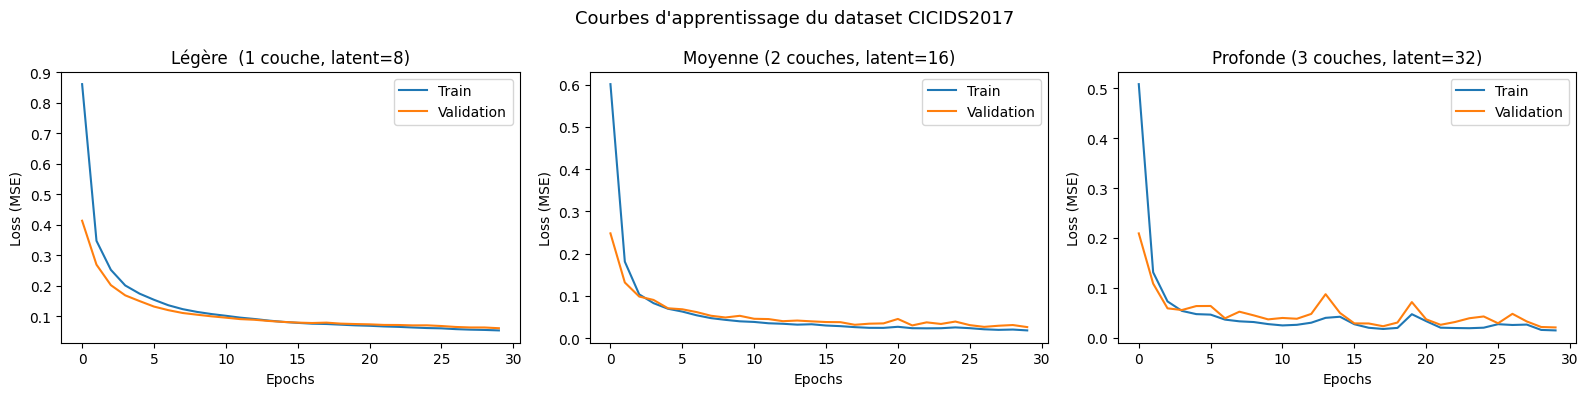

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, res in zip(axes, resultats_cicids):
    ax.plot(res['history'].history['loss'],label='Train')
    ax.plot(res['history'].history['val_loss'], label='Validation')
    ax.set(title=res['Architecture'], xlabel='Epochs', ylabel='Loss (MSE)')
    ax.legend()

plt.suptitle('Courbes d\'apprentissage du dataset CICIDS2017', fontsize=13)
plt.tight_layout()
plt.show()

Les trois courbes montrent une convergence en effet la courbe descend vite au début puis devient plate ce qui veut dire que le modèle apprend beaucoup au début puis atteint un plateau où il ne peut plus vraiment s'améliorer. 
L'architecture légère a une convergence stable et régulière, train et validation très proches tout au long et pas de surapprentissage. L'erreur de reconstruction finale est autour de 0.08.
L'architecture moyenne a une convergence plus rapide et l'erreur de reconstruction finale plus basse (environ 0.05) ainsi le modèle apprend mieux grâce aux couches supplémentaires. Train et validation restent collées.
L'architecture profonde a des oscillations sur la courbe de validation à partir de l'epoch 15 c'est le signe d'une légère instabilité. L'erreur de reconstruction finale est très basse (environ 0.03) mais ces oscillations expliquent pourquoi cette architecture détectait si peu d'attaques (recall de 4%) car elle reconstruit un peu trop bien tout, y compris les anomalies.

### 1.4 Distribution des erreurs de reconstruction

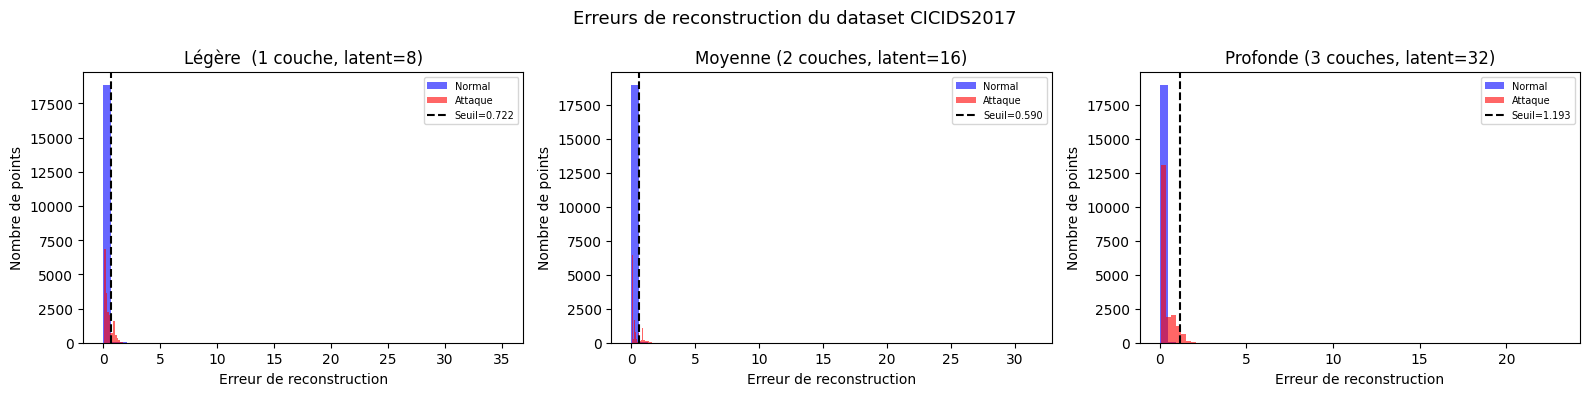

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, res in zip(axes, resultats_cicids):
    ax.hist(res['erreurs'][y_test == 0], bins=50, alpha=0.6, label='Normal',  color='blue')
    ax.hist(res['erreurs'][y_test == 1], bins=50, alpha=0.6, label='Attaque', color='red')
    ax.axvline(res['seuil'], color='black', linestyle='--', label=f'Seuil={res["seuil"]:.3f}')
    ax.set(title=res['Architecture'], xlabel='Erreur de reconstruction', ylabel='Nombre de points')
    ax.legend(fontsize=7)

plt.suptitle('Erreurs de reconstruction du dataset CICIDS2017', fontsize=13)
plt.tight_layout()

plt.show()

Les trois graphes montrent que la grande majorité des points normaux comme attaques ont une erreur de reconstruction très faible proche de 0, ce qui explique pourquoi les distributions sont toutes concentrées à gauche.
On remarque que pour la légère (seuil=0.722) et la moyenne (seuil=0.590), le seuil est placé juste après la masse principale des points donc quelques attaques dépassent ce seuil ce qui explique les recalls de 20% et 23%. Pour la profonde (seuil=1.193), le seuil est beaucoup plus à droite et presque aucune attaque ne le dépasse, ce qui confirme le recall de 4%.


## Dataset  UNSW-NB15

### 2.1 Préparation des données

In [10]:
X = df_unsw.drop(columns=['Label']).select_dtypes(include=[np.number])
y_unsw = df_unsw['Label'].values  # 0 pour normal et 1 pour attaque
X = X.fillna(0).replace([np.inf, -np.inf], 0)
X_scaled = StandardScaler().fit_transform(X)

X_normal  = X_scaled[y_unsw == 0]
X_attaque = X_scaled[y_unsw == 1]

X_train, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=42)

n_test = len(X_test_normal)
idx = np.random.choice(len(X_attaque), size=min(n_test, len(X_attaque)), replace=False)
X_test = np.vstack([X_test_normal, X_attaque[idx]])
y_test = np.array([0] * n_test + [1] * len(idx))

print(f"Train (normaux) : {X_train.shape}")
print(f"Test (normaux et attaques ) : {X_test.shape} et {y_test.mean():.2%} d'attaques")

Train (normaux) : (542228, 44)
Test (normaux et attaques ) : (157773, 44) et 14.08% d'attaques


### 2.2 Test de différentes architectures

In [12]:
input_dim = X_train.shape[1]
resultats_unsw = []

for arch in architectures:
    print(f"\nArchitecture : {arch['nom']}")

    model = build_autoencoder(input_dim, arch['latent'], arch['hidden'])
    history = model.fit(
        X_train, X_train,
        epochs=30,
        batch_size=256,
        validation_split=0.1,
        verbose=0)

    reconstructions_train = model.predict(X_train, verbose=0)
    erreurs_train = np.mean((X_train - reconstructions_train) ** 2, axis=1)
    seuil = erreurs_train.mean() + 2 * erreurs_train.std()

    pred, erreurs_test = detecter_anomalies(model, X_test, seuil)
    auc = roc_auc_score(y_test, erreurs_test)

    print(classification_report(y_test, pred, target_names=['Normal', 'Attaque']))
    print(f"AUC-ROC : {auc:.3f}  et seuil : {seuil:.4f}")

    resultats_unsw.append({
        'Architecture': arch['nom'],
        'history'     : history,
        'erreurs'     : erreurs_test,
        'pred'        : pred,
        'seuil'       : seuil,
        'auc'         : auc })


Architecture : Légère  (1 couche, latent=8)


              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00    135558
     Attaque       0.96      1.00      0.98     22215

    accuracy                           0.99    157773
   macro avg       0.98      0.99      0.99    157773
weighted avg       0.99      0.99      0.99    157773

AUC-ROC : 0.998  et seuil : 0.4552

Architecture : Moyenne (2 couches, latent=16)
              precision    recall  f1-score   support

      Normal       0.90      1.00      0.95    135558
     Attaque       1.00      0.34      0.50     22215

    accuracy                           0.91    157773
   macro avg       0.95      0.67      0.73    157773
weighted avg       0.92      0.91      0.89    157773

AUC-ROC : 1.000  et seuil : 1.2335

Architecture : Profonde (3 couches, latent=32)
              precision    recall  f1-score   support

      Normal       0.86      1.00      0.92    135558
     Attaque       0.95      0.00      0.00     22215

    accuracy     

L'architecture légère est clairement la meilleure avec un f1 de 0.98 sur les attaques, recall de 100% et AUC de 0.998. Elle détecte pratiquement toutes les attaques tout en générant très peu de fausses alertes.
L'architecture moyenne obtient une AUC parfaite de 1.000 mais son seuil très élevé (1.23) fait chuter le recall à seulement 34% donc le modèle est trop sélectif et rate la majorité des attaques malgré une excellente capacité de séparation théorique.
L'architecture profonde est inutilisable avec un recall de 0% sur les attaques avec un seuil absurde de 9.17. Elle reconstruit trop bien tout, y compris les attaques, ce qui confirme qu'une architecture trop complexe est contre-productive pour ce type de détection.


### 2.3 Courbes d'apprentissage

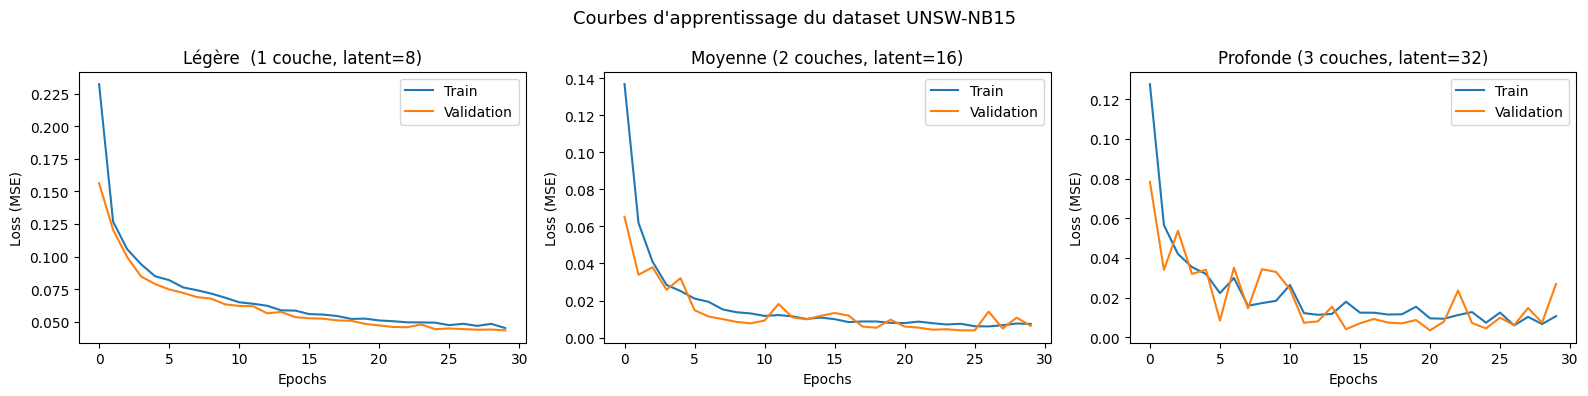

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, res in zip(axes, resultats_unsw):
    ax.plot(res['history'].history['loss'],     label='Train')
    ax.plot(res['history'].history['val_loss'], label='Validation')
    ax.set(title=res['Architecture'], xlabel='Epochs', ylabel='Loss (MSE)')
    ax.legend()

plt.suptitle('Courbes d\'apprentissage du dataset UNSW-NB15', fontsize=13)
plt.tight_layout()
plt.show()

L'architecture légère a une convergence propre et régulière, train et validation descendent ensemble et se stabilisent autour de 0.05. En effet le modèle apprend bien sans surapprentissage, ce qui explique ses excellentes performances.
L'architecture moyenne a une convergence plus rapide et l'erreur de reconstruction finale est très basse (environ 0.01). Train et validation restent proches jusqu'à l'epoch 20 puis la validation remonte légèrement, c'est un signe d'un début de surapprentissage. C'est ce qui pousse le seuil à la hausse (1.23) et fait chuter le recall.
L'architecture profonde a des oscillations très prononcées sur les deux courbes car le modèle n'arrive pas à se stabiliser. Cette instabilité explique le seuil aberrant de 9.17 et le recall nul sur les attaques. L'architecture est trop complexe pour ce dataset.

### 2.4 Distribution des erreurs de reconstruction

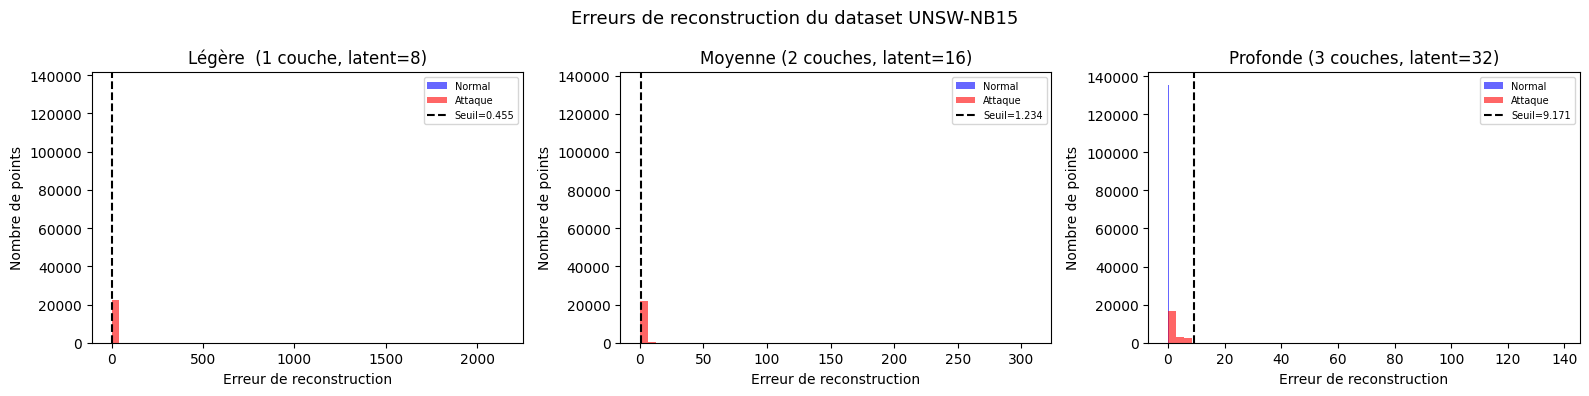

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, res in zip(axes, resultats_unsw):
    ax.hist(res['erreurs'][y_test == 0], bins=50, alpha=0.6, label='Normal',  color='blue')
    ax.hist(res['erreurs'][y_test == 1], bins=50, alpha=0.6, label='Attaque', color='red')
    ax.axvline(res['seuil'], color='black', linestyle='--', label=f'Seuil={res["seuil"]:.3f}')
    ax.set(title=res['Architecture'], xlabel='Erreur de reconstruction', ylabel='Nombre de points')
    ax.legend(fontsize=7)

plt.suptitle('Erreurs de reconstruction du dataset UNSW-NB15', fontsize=13)
plt.tight_layout()
plt.show()

Les trois graphes confirment parfaitement les résultats obtenus.
Architecture légère  possède  des attaques qui ont des erreurs très élevées allant jusqu'à 2000, bien au-delà du seuil à 0.455. Les normaux sont tous concentrés à 0. La séparation est quasi parfaite ce qui explique le recall de 100%.
Architecture moyenne a le même pattern mais les erreurs des attaques sont moins extrêmes. Le seuil à 1.234 est bien placé mais une partie des attaques reste sous ce seuil expliquant le recall de 34%.
Architecture profonde a un seuil à 9.171 assez élevé ainsi on voit que les attaques qui ont des erreurs comprises entre 0 et 20, donc la plupart sont en dessous du seuil. C'est pour ça que le recall est de 0% .


## Dataset 3 : Cybersecurity Threat Detection Logs

### 3.1 Préparation des données
Le dataset contien t6 millions de lignes ainsi l'entraînement est trop long pour cela on réduit en créant un échantillon plus petit.

In [18]:
# encodage des colonnes catégorielles
df_enc = df_logs.copy()
for col in ['protocol', 'action', 'log_type']:
    if col in df_enc.columns:
        df_enc[col + '_enc'] = LabelEncoder().fit_transform(df_enc[col].astype(str))

features = ['bytes_transferred'] + [c for c in df_enc.columns if c.endswith('_enc')]
X = df_enc[features].fillna(0)
y_logs = (df_logs['threat_label'] != 'benign').astype(int)
X_scaled = StandardScaler().fit_transform(X)

X_normal  = X_scaled[y_logs == 0]
X_attaque = X_scaled[y_logs == 1]

# on crée un échantillon de 50 000 normaux 
idx_sample = np.random.choice(len(X_normal), size=50000, replace=False)
X_normal = X_normal[idx_sample]

X_train, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=42)

n = len(X_test_normal)
idx = np.random.choice(len(X_attaque), size=min(n, len(X_attaque)), replace=False)
X_test = np.vstack([X_test_normal, X_attaque[idx]])
y_test = np.array([0] * n + [1] * len(idx))

print(f"Train (normaux) : {X_train.shape}")
print(f"Test (normaux et attaques): {X_test.shape} et {y_test.mean():.2%} d'anomalies")

Train (normaux) : (40000, 4)
Test (normaux et attaques): (20000, 4) et 50.00% d'anomalies


### 3.2 Test de différentes architectures

In [19]:
input_dim = X_train.shape[1]
resultats_logs = []

architectures_logs = [
    {'nom': 'Légère  (1 couche, latent=2)',  'hidden': [8],     'latent': 2},
    {'nom': 'Moyenne (2 couches, latent=2)', 'hidden': [16, 8], 'latent': 2},
    {'nom': 'Profonde (2 couches, latent=3)','hidden': [16, 8], 'latent': 3},
]

for arch in architectures_logs:
    print(f"\nArchitecture : {arch['nom']}")

    model = build_autoencoder(input_dim, arch['latent'], arch['hidden'])
    history = model.fit(
        X_train, X_train,
        epochs=15,        # réduit pour accélérer
        batch_size=512,   # augmenté pour accélérer
        validation_split=0.1,
        verbose=0
    )

    erreurs_train = np.mean((X_train - model.predict(X_train, verbose=0)) ** 2, axis=1)
    seuil = erreurs_train.mean() + 2 * erreurs_train.std()

    pred, erreurs_test = detecter_anomalies(model, X_test, seuil)
    auc = roc_auc_score(y_test, erreurs_test)

    print(classification_report(y_test, pred, target_names=['Normal', 'Anomalie']))
    print(f"AUC-ROC : {auc:.3f} et seuil : {seuil:.4f}")

    resultats_logs.append({
        'Architecture': arch['nom'],
        'history'     : history,
        'erreurs'     : erreurs_test,
        'pred'        : pred,
        'seuil'       : seuil,
        'auc'         : auc
    })


Architecture : Légère  (1 couche, latent=2)
              precision    recall  f1-score   support

      Normal       0.50      0.95      0.66     10000
    Anomalie       0.51      0.05      0.09     10000

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.37     20000
weighted avg       0.50      0.50      0.37     20000

AUC-ROC : 0.502 et seuil : 1.0074

Architecture : Moyenne (2 couches, latent=2)
              precision    recall  f1-score   support

      Normal       0.50      0.95      0.66     10000
    Anomalie       0.51      0.05      0.09     10000

    accuracy                           0.50     20000
   macro avg       0.51      0.50      0.37     20000
weighted avg       0.51      0.50      0.37     20000

AUC-ROC : 0.458 et seuil : 0.8176

Architecture : Profonde (2 couches, latent=3)
              precision    recall  f1-score   support

      Normal       0.50      0.93      0.65     10000
    Anomalie       0.50      0.

Les trois architectures donnent des résultats presque identiques et tous plutôt mauvais avec un f1 entre 0.09 et 0.13 sur les anomalies et des AUC autour de 0.5, soit le niveau d'un modèle aléatoire. L'autoencoder ne parvient pas à distinguer les anomalies des connexions normales, quelle que soit l'architecture testée.
La raison est la même que pour les notebooks précédents avec seulement 4 features (bytes_transferred, protocol, action, log_type), l'autoencoder n'a pas assez d'information pour apprendre une représentation significative du trafic normal. Les anomalies ont exactement les mêmes valeurs que les connexions normales .

### 3.3 Courbes d'apprentissage

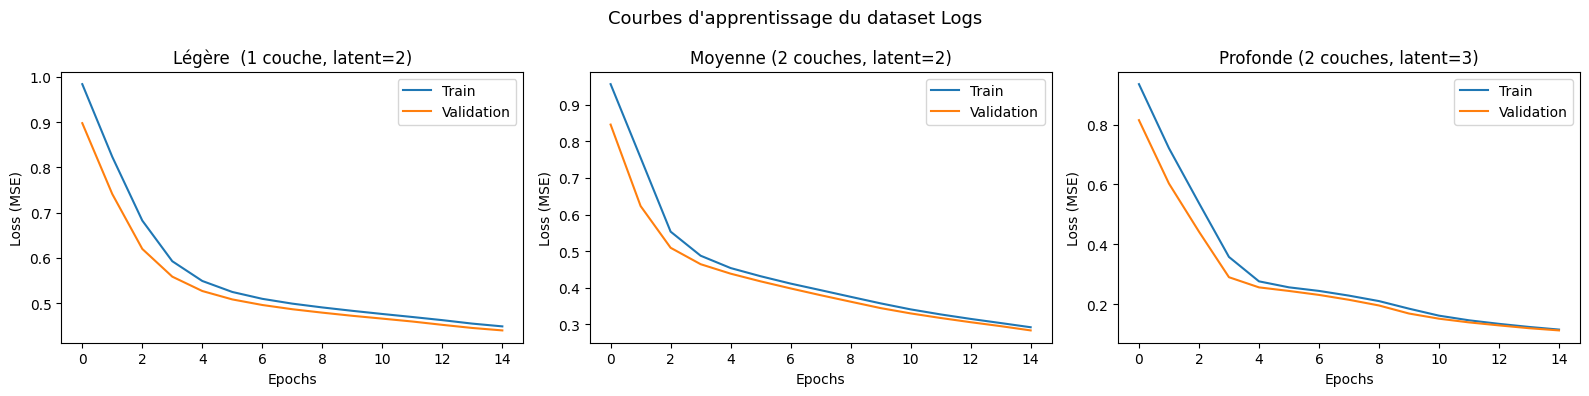

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, res in zip(axes, resultats_logs):
    ax.plot(res['history'].history['loss'],label='Train')
    ax.plot(res['history'].history['val_loss'], label='Validation')
    ax.set(title=res['Architecture'], xlabel='Epochs', ylabel='Loss (MSE)')
    ax.legend()

plt.suptitle('Courbes d\'apprentissage du dataset Logs', fontsize=13)
plt.tight_layout()
plt.show()

Les trois courbes montrent une convergence correcte l'erreur de reconstruction diminue régulièrement sur les 15 epochs sans oscillations ni divergence. Train et validation restent proches sur les trois architectures, ce qui indique qu'il n'y a pas de surapprentissage.
Cependant l'erreur de reconstruction finale reste élevée autour de 0.3 à 0.5 cela signifie que même après entraînement, le modèle reconstruit mal le trafic normal, ce qui est directement lié au très faible nombre de features disponibles (4 seulement). 

### 3.4 Distribution des erreurs de reconstruction

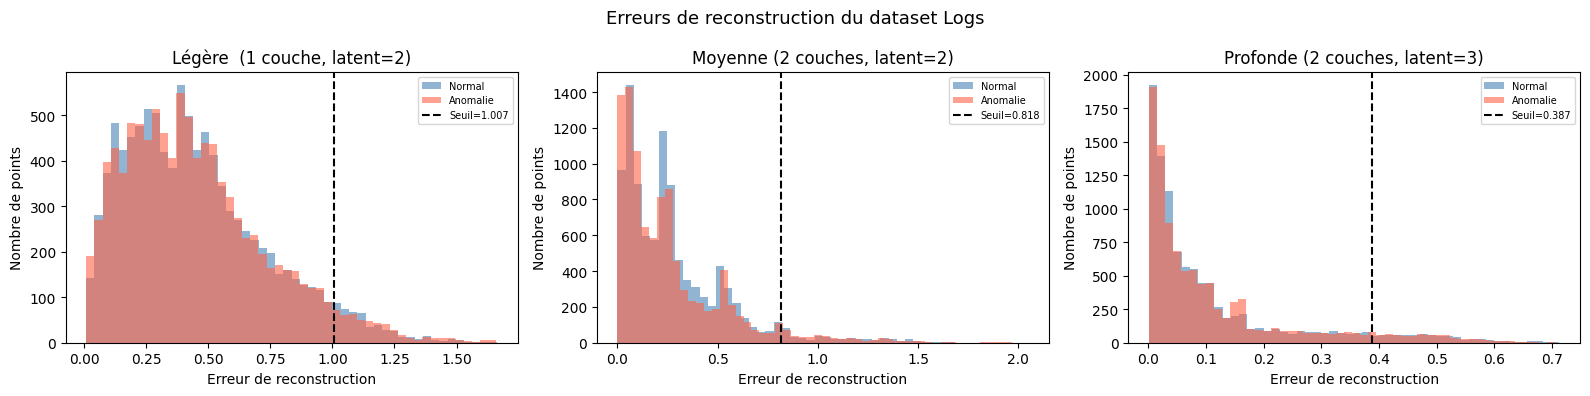

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, res in zip(axes, resultats_logs):
    ax.hist(res['erreurs'][y_test == 0], bins=50, alpha=0.6, label='Normal',   color='steelblue')
    ax.hist(res['erreurs'][y_test == 1], bins=50, alpha=0.6, label='Anomalie', color='tomato')
    ax.axvline(res['seuil'], color='black', linestyle='--', label=f'Seuil={res["seuil"]:.3f}')
    ax.set(title=res['Architecture'], xlabel='Erreur de reconstruction', ylabel='Nombre de points')
    ax.legend(fontsize=7)

plt.suptitle('Erreurs de reconstruction du dataset Logs', fontsize=13)
plt.tight_layout()
plt.show()

Les trois graphes confirment l'échec du modèle sur ce dataset.
Contrairement à UNSW-NB15 où les distributions Normal et Attaque étaient clairement séparées, ici les deux distributions se chevauchent complètement ainsi normaux et anomalies ont exactement les mêmes erreurs de reconstruction sur les trois architectures. Le seuil ne peut donc pas séparer proprement les deux classes quelle que soit sa position.
